# Diabetes Prediction — Revision V2

This notebook replaces the original leakage-prone diabetes experiment with a reviewer-ready, leakage-free evaluation.

## Corrections implemented
- The **original 768-record diabetes dataset is split first** using a stratified 80/20 train–test split.
- No duplicated observation is created before the split.
- Physiologically implausible zero values in selected clinical measurements are treated as missing **within the modeling pipeline**, followed by training-fold median imputation.
- Scaling and random oversampling are performed **inside training folds only**.
- The held-out test set is never oversampled, used for hyperparameter optimization, calibration fitting, or threshold selection.
- `classification_report(y_test, y_pred)` is used in the correct order.
- ROC–AUC and PR–AUC are calculated from **predicted probabilities**, not hard class labels.
- Five boosting algorithms are optimized using stratified cross-validation on the training data only.
- Probability calibration is performed using training data only.
- A classification threshold is selected from **out-of-fold training probabilities** using Youden's J statistic and then locked.
- Results are reported at both the default 0.50 threshold and the training-derived threshold.
- Accuracy, balanced accuracy, precision, sensitivity, specificity, F1-score, ROC–AUC, PR–AUC, Brier score, confusion matrices, and bootstrap 95% confidence intervals are produced.
- Repeated stratified cross-validation outputs are generated for the revised statistical analysis.
- SHAP and LIME are regenerated from the corrected leakage-free model.
- SHAP/LIME findings are interpreted as explanations of model behavior rather than causal clinical effects.

> **Important:** The purpose of this revision is not to reproduce the leakage-inflated 90.62% accuracy.  
> The objective is to obtain defensible performance estimates under a transparent, leakage-free protocol.


In [1]:
# Optional installation if required
# !pip install -q imbalanced-learn xgboost lightgbm catboost shap lime

import warnings, time, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone, BaseEstimator, TransformerMixin
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
    GridSearchCV, cross_validate, cross_val_predict
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, classification_report, balanced_accuracy_score,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Load the original diabetes dataset

The notebook expects the same raw file used by the original repository: `diabetes(1).csv`.

Expected predictors:
`PG`, `GL`, `BP`, `ST`, `IN`, `BMI`, `DPF`, `AG`

Target:
`DB`


In [2]:
DATA_PATH = "diabetes(1).csv"
TARGET = "DB"

data = pd.read_csv(DATA_PATH).copy()
data.columns = [c.strip() for c in data.columns]

expected_cols = ["PG","GL","BP","ST","IN","BMI","DPF","AG","DB"]

print("Original shape:", data.shape)
print("Columns:", list(data.columns))

missing_expected = [c for c in expected_cols if c not in data.columns]
if missing_expected:
    raise ValueError(
        f"Expected columns not found: {missing_expected}. "
        f"Available columns: {list(data.columns)}"
    )

data = data[expected_cols].copy()
data[TARGET] = data[TARGET].astype(int)

print("\nTarget distribution:")
print(data[TARGET].value_counts().sort_index())

display(data.head())


Original shape: (768, 9)
Columns: ['PG', 'GL', 'BP', 'ST', 'IN', 'BMI', 'DPF', 'AG', 'DB']

Target distribution:
DB
0    500
1    268
Name: count, dtype: int64


,PG,GL,BP,ST,IN,BMI,DPF,AG,DB
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Split first — before any fitted preprocessing or resampling

The original dataset is divided into stratified 80% training and 20% test subsets.  
The test set remains untouched until final evaluation.


In [3]:
X = data.drop(columns=[TARGET]).copy()
y = data[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nUntouched test class distribution:")
print(y_test.value_counts().sort_index())

assert len(X_train) + len(X_test) == len(data)
assert set(X_train.index).isdisjoint(set(X_test.index))

print("\nLeakage safeguard passed: original train/test indices do not overlap.")


Training shape: (614, 8)
Test shape: (154, 8)

Training class distribution:
DB
0    400
1    214
Name: count, dtype: int64

Untouched test class distribution:
DB
0    100
1     54
Name: count, dtype: int64

Leakage safeguard passed: original train/test indices do not overlap.


## 3. Training-fold preprocessing

For this dataset, zeros in the following physiological measurements are treated as missing values rather than valid measurements:

- Glucose (`GL`)
- Blood pressure (`BP`)
- Skin thickness (`ST`)
- Insulin (`IN`)
- Body mass index (`BMI`)

Pregnancies (`PG`) may legitimately be zero and is therefore left unchanged.  
The zero-to-missing conversion is deterministic; median imputation is then learned **only from each training fold**.

The original repository used duplication-based oversampling rather than SMOTE. Therefore, the corrected experiment uses `RandomOverSampler` inside the training pipeline.


In [4]:
class ZeroAsMissingTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None, feature_names=None):
        self.columns = columns or []
        self.feature_names = feature_names or []

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            Xc = X.copy()
            for col in self.columns:
                if col in Xc.columns:
                    Xc[col] = Xc[col].replace(0, np.nan)
            return Xc

        Xc = np.asarray(X, dtype=float).copy()
        if self.feature_names:
            name_to_idx = {name: i for i, name in enumerate(self.feature_names)}
            for col in self.columns:
                if col in name_to_idx:
                    Xc[:, name_to_idx[col]] = np.where(
                        Xc[:, name_to_idx[col]] == 0,
                        np.nan,
                        Xc[:, name_to_idx[col]]
                    )
        return Xc

FEATURE_NAMES = list(X.columns)
ZERO_AS_MISSING = ["GL", "BP", "ST", "IN", "BMI"]

def make_pipeline(model):
    return Pipeline([
        ("zero_as_missing",
         ZeroAsMissingTransformer(
             columns=ZERO_AS_MISSING,
             feature_names=FEATURE_NAMES
         )),
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler()),
        ("oversampler", RandomOverSampler(random_state=RANDOM_STATE)),
        ("model", model),
    ])


## 4. Model search spaces

The original code used very large fixed numbers of estimators and no reproducible cross-validated model-selection process.  
The revised search uses conservative model-specific ranges to reduce overfitting while allowing adequate flexibility.


In [5]:
models_and_grids = {
    "XGBoost": (
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        {
            "model__n_estimators": [200, 500, 800],
            "model__learning_rate": [0.02, 0.05, 0.10],
            "model__max_depth": [2, 3, 5],
            "model__min_child_weight": [1, 3, 5],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0],
        }
    ),

    "CatBoost": (
        CatBoostClassifier(
            verbose=0,
            random_seed=RANDOM_STATE
        ),
        {
            "model__iterations": [200, 500, 800],
            "model__learning_rate": [0.02, 0.05, 0.10],
            "model__depth": [3, 5, 7],
            "model__l2_leaf_reg": [3, 7, 12],
        }
    ),

    "LightGBM": (
        LGBMClassifier(
            boosting_type="gbdt",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1
        ),
        {
            "model__n_estimators": [200, 500, 800],
            "model__learning_rate": [0.02, 0.05, 0.10],
            "model__max_depth": [2, 3, 5],
            "model__num_leaves": [7, 15, 31],
            "model__min_child_samples": [10, 20, 30],
        }
    ),

    "AdaBoost": (
        AdaBoostClassifier(random_state=RANDOM_STATE),
        {
            "model__n_estimators": [100, 300, 500],
            "model__learning_rate": [0.02, 0.05, 0.10, 0.50],
        }
    ),

    "GradientBoosting": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {
            "model__n_estimators": [100, 300, 500],
            "model__learning_rate": [0.02, 0.05, 0.10],
            "model__max_depth": [1, 2, 3],
            "model__min_samples_leaf": [1, 3, 5, 10],
            "model__subsample": [0.8, 1.0],
        }
    ),
}


## 5. Hyperparameter optimization on training data only

The primary tuning criterion is **balanced accuracy** because the diabetes classes are imbalanced and the revised manuscript should not select models primarily by overall accuracy.

Five-fold stratified cross-validation is used for every model.


In [6]:
inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

best_estimators = {}
search_objects = {}
tuning_rows = []

for name, (model, grid) in models_and_grids.items():
    print(f"\nTuning {name} ...")

    search = GridSearchCV(
        estimator=make_pipeline(model),
        param_grid=grid,
        scoring="balanced_accuracy",
        cv=inner_cv,
        refit=True,
        n_jobs=-1,
        return_train_score=False
    )

    t0 = time.perf_counter()
    search.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0

    best_estimators[name] = search.best_estimator_
    search_objects[name] = search

    tuning_rows.append({
        "Model": name,
        "Best_CV_Balanced_Accuracy": search.best_score_,
        "Tuning_Time_sec": elapsed,
        "Best_Params": json.dumps(
            {k.replace("model__", ""): v for k, v in search.best_params_.items()}
        )
    })

tuning_df = pd.DataFrame(tuning_rows).sort_values(
    "Best_CV_Balanced_Accuracy",
    ascending=False
)

display(tuning_df)
tuning_df.to_csv("DB_V2_hyperparameters.csv", index=False)



Tuning XGBoost ...

Tuning CatBoost ...

Tuning LightGBM ...

Tuning AdaBoost ...

Tuning GradientBoosting ...


,Model,Best_CV_Balanced_Accuracy,Tuning_Time_sec,Best_Params
0,XGBoost,0.767937,7.818676,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0..."
2,LightGBM,0.767882,84.643433,"{""learning_rate"": 0.02, ""max_depth"": 3, ""min_c..."
4,GradientBoosting,0.762798,15.440605,"{""learning_rate"": 0.1, ""max_depth"": 1, ""min_sa..."
1,CatBoost,0.762449,32.026551,"{""depth"": 3, ""iterations"": 200, ""l2_leaf_reg"":..."
3,AdaBoost,0.750876,2.003963,"{""learning_rate"": 0.02, ""n_estimators"": 300}"


## 6. Training-only probability calibration

Sigmoid/Platt calibration is fitted using only the training data.  
The held-out test set is not used to fit calibration parameters.


In [7]:
calibration_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

calibrated_models = {}

for name, estimator in best_estimators.items():
    calibrated = CalibratedClassifierCV(
        estimator=clone(estimator),
        method="sigmoid",
        cv=calibration_cv
    )
    calibrated.fit(X_train, y_train)
    calibrated_models[name] = calibrated

print("Calibrated models:", list(calibrated_models))


Calibrated models: ['XGBoost', 'CatBoost', 'LightGBM', 'AdaBoost', 'GradientBoosting']


## 7. Training-only threshold optimization

For each model, calibrated out-of-fold probabilities are generated from the **training set only**.  
Youden's J statistic selects a threshold that balances sensitivity and specificity.

The threshold is locked before final evaluation on the held-out test set.


In [8]:
def choose_youden_threshold(y_true, prob):
    fpr, tpr, thresholds = roc_curve(y_true, prob)
    valid = np.isfinite(thresholds)
    fpr = fpr[valid]
    tpr = tpr[valid]
    thresholds = thresholds[valid]
    j = tpr - fpr
    return float(thresholds[np.argmax(j)])

threshold_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE + 101
)

locked_thresholds = {}
oof_probabilities = {}
threshold_rows = []

for name, estimator in best_estimators.items():
    print("Generating training-only OOF probabilities:", name)

    calibrator_for_oof = CalibratedClassifierCV(
        estimator=clone(estimator),
        method="sigmoid",
        cv=3
    )

    oof_prob = cross_val_predict(
        calibrator_for_oof,
        X_train,
        y_train,
        cv=threshold_cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    threshold = choose_youden_threshold(
        y_train.to_numpy(),
        oof_prob
    )

    pred_oof = (oof_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_train,
        pred_oof,
        labels=[0, 1]
    ).ravel()

    locked_thresholds[name] = threshold
    oof_probabilities[name] = oof_prob

    threshold_rows.append({
        "Model": name,
        "Locked_Threshold": threshold,
        "OOF_Accuracy": accuracy_score(y_train, pred_oof),
        "OOF_Balanced_Accuracy": balanced_accuracy_score(y_train, pred_oof),
        "OOF_Precision": precision_score(y_train, pred_oof, zero_division=0),
        "OOF_Sensitivity": recall_score(y_train, pred_oof, zero_division=0),
        "OOF_Specificity": tn/(tn+fp),
        "OOF_F1": f1_score(y_train, pred_oof, zero_division=0),
        "OOF_ROC_AUC": roc_auc_score(y_train, oof_prob),
        "OOF_PR_AUC": average_precision_score(y_train, oof_prob),
        "OOF_Brier": brier_score_loss(y_train, oof_prob)
    })

threshold_df = pd.DataFrame(threshold_rows).sort_values(
    ["OOF_Balanced_Accuracy", "OOF_ROC_AUC"],
    ascending=False
)

display(threshold_df)
threshold_df.to_csv("DB_V2_training_only_thresholds.csv", index=False)


Generating training-only OOF probabilities: XGBoost
Generating training-only OOF probabilities: CatBoost
Generating training-only OOF probabilities: LightGBM
Generating training-only OOF probabilities: AdaBoost
Generating training-only OOF probabilities: GradientBoosting


,Model,Locked_Threshold,OOF_Accuracy,OOF_Balanced_Accuracy,OOF_Precision,OOF_Sensitivity,OOF_Specificity,OOF_F1,OOF_ROC_AUC,OOF_PR_AUC,OOF_Brier
3,AdaBoost,0.369017,0.775244,0.777523,0.646154,0.785047,0.7700,0.708861,0.847617,0.735572,0.151867
1,CatBoost,0.373621,0.781759,0.777091,0.662602,0.761682,0.7925,0.708696,0.842722,0.719642,0.152024
0,XGBoost,0.274559,0.750814,0.775070,0.600000,0.855140,0.6950,0.705202,0.847231,0.732911,0.150458
4,GradientBoosting,0.277162,0.741042,0.769743,0.587302,0.864486,0.6750,0.699433,0.843166,0.727635,0.152043
2,LightGBM,0.317214,0.750814,0.767465,0.604811,0.822430,0.7125,0.697030,0.837068,0.713446,0.154858


## 8. Final evaluation on the untouched test set

Sensitivity refers to detection of diabetes (`DB = 1`), while specificity refers to correct identification of non-diabetes (`DB = 0`).


In [9]:
def metric_bundle(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0,1]
    ).ravel()

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "Specificity": tn/(tn+fp) if (tn+fp) else np.nan,
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob),
        "Brier": brier_score_loss(y_true, y_prob),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

test_rows = []
prediction_store = {}

for name, model in calibrated_models.items():
    prob = model.predict_proba(X_test)[:,1]

    pred_default = (prob >= 0.50).astype(int)
    pred_locked = (
        prob >= locked_thresholds[name]
    ).astype(int)

    default_metrics = metric_bundle(
        y_test,
        pred_default,
        prob
    )

    locked_metrics = metric_bundle(
        y_test,
        pred_locked,
        prob
    )

    prediction_store[name] = {
        "prob": prob,
        "pred_default": pred_default,
        "pred_locked": pred_locked
    }

    test_rows.append({
        "Model": name,
        "Threshold_Type": "Default_0.50",
        "Threshold": 0.50,
        **default_metrics
    })

    test_rows.append({
        "Model": name,
        "Threshold_Type": "Training_Optimized",
        "Threshold": locked_thresholds[name],
        **locked_metrics
    })

test_results_df = pd.DataFrame(test_rows)

display(test_results_df)

test_results_df.to_csv(
    "DB_V2_test_results_default_and_optimized.csv",
    index=False
)


,Model,Threshold_Type,Threshold,Accuracy,Balanced_Accuracy,Precision,Sensitivity,Specificity,F1,ROC_AUC,PR_AUC,Brier,TN,FP,FN,TP
0,XGBoost,Default_0.50,0.500000,0.733766,0.697037,0.632653,0.574074,0.82,0.601942,0.819259,0.679970,0.164468,82,18,23,31
1,XGBoost,Training_Optimized,0.274559,0.740260,0.770185,0.587500,0.870370,0.67,0.701493,0.819259,0.679970,0.164468,67,33,7,47
2,CatBoost,Default_0.50,0.500000,0.733766,0.701296,0.627451,0.592593,0.81,0.609524,0.817407,0.671363,0.166986,81,19,22,32
3,CatBoost,Training_Optimized,0.373621,0.746753,0.745370,0.615385,0.740741,0.75,0.672269,0.817407,0.671363,0.166986,75,25,14,40
4,LightGBM,Default_0.50,0.500000,0.753247,0.716296,0.666667,0.592593,0.84,0.627451,0.821481,0.665180,0.163435,84,16,22,32
5,LightGBM,Training_Optimized,0.317214,0.746753,0.766667,0.600000,0.833333,0.70,0.697674,0.821481,0.665180,0.163435,70,30,9,45
6,AdaBoost,Default_0.50,0.500000,0.740260,0.689259,0.666667,0.518519,0.86,0.583333,0.823796,0.677510,0.163490,86,14,26,28
7,AdaBoost,Training_Optimized,0.369017,0.746753,0.749630,0.611940,0.759259,0.74,0.677686,0.823796,0.677510,0.163490,74,26,13,41
8,GradientBoosting,Default_0.50,0.500000,0.746753,0.707037,0.659574,0.574074,0.84,0.613861,0.824259,0.696977,0.161398,84,16,23,31
9,GradientBoosting,Training_Optimized,0.277162,0.733766,0.756667,0.584416,0.833333,0.68,0.687023,0.824259,0.696977,0.161398,68,32,9,45


## 9. Bootstrap 95% confidence intervals

In [10]:
METRICS_FOR_CI = [
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Sensitivity",
    "Specificity",
    "F1",
    "ROC_AUC",
    "PR_AUC",
    "Brier"
]

def bootstrap_metric_cis(
    y_true,
    pred,
    prob,
    n_boot=3000,
    seed=RANDOM_STATE
):
    rng = np.random.default_rng(seed)

    y_true = np.asarray(y_true)
    pred = np.asarray(pred)
    prob = np.asarray(prob)

    n = len(y_true)
    values = {m: [] for m in METRICS_FOR_CI}

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)

        yt = y_true[idx]
        yp = pred[idx]
        ypr = prob[idx]

        if len(np.unique(yt)) < 2:
            continue

        metrics = metric_bundle(
            yt,
            yp,
            ypr
        )

        for metric in METRICS_FOR_CI:
            if np.isfinite(metrics[metric]):
                values[metric].append(
                    metrics[metric]
                )

    return {
        metric: (
            np.percentile(values[metric], 2.5),
            np.percentile(values[metric], 97.5)
        )
        for metric in METRICS_FOR_CI
    }

ci_rows = []

for name, stored in prediction_store.items():

    for threshold_type, pred_key, threshold in [
        ("Default_0.50", "pred_default", 0.50),
        (
            "Training_Optimized",
            "pred_locked",
            locked_thresholds[name]
        )
    ]:

        pred = stored[pred_key]
        prob = stored["prob"]

        point = metric_bundle(
            y_test,
            pred,
            prob
        )

        cis = bootstrap_metric_cis(
            y_test,
            pred,
            prob
        )

        row = {
            "Model": name,
            "Threshold_Type": threshold_type,
            "Threshold": threshold
        }

        for metric in METRICS_FOR_CI:
            row[metric] = point[metric]
            row[f"{metric}_95CI"] = (
                f"{cis[metric][0]:.3f}–{cis[metric][1]:.3f}"
            )

        ci_rows.append(row)

ci_df = pd.DataFrame(ci_rows)

display(ci_df)

ci_df.to_csv(
    "DB_V2_results_with_95CI.csv",
    index=False
)


,Model,Threshold_Type,Threshold,Accuracy,Accuracy_95CI,Balanced_Accuracy,Balanced_Accuracy_95CI,Precision,Precision_95CI,Sensitivity,...,Specificity,Specificity_95CI,F1,F1_95CI,ROC_AUC,ROC_AUC_95CI,PR_AUC,PR_AUC_95CI,Brier,Brier_95CI
0,XGBoost,Default_0.50,0.500000,0.733766,0.662–0.799,0.697037,0.619–0.770,0.632653,0.491–0.765,0.574074,...,0.82,0.742–0.890,0.601942,0.484–0.703,0.819259,0.747–0.882,0.679970,0.550–0.803,0.164468,0.134–0.199
1,XGBoost,Training_Optimized,0.274559,0.740260,0.669–0.805,0.770185,0.704–0.832,0.587500,0.479–0.691,0.870370,...,0.67,0.576–0.758,0.701493,0.607–0.784,0.819259,0.747–0.882,0.679970,0.550–0.803,0.164468,0.134–0.199
2,CatBoost,Default_0.50,0.500000,0.733766,0.662–0.799,0.701296,0.624–0.777,0.627451,0.491–0.759,0.592593,...,0.81,0.730–0.883,0.609524,0.495–0.712,0.817407,0.745–0.880,0.671363,0.540–0.800,0.166986,0.135–0.203
3,CatBoost,Training_Optimized,0.373621,0.746753,0.682–0.812,0.745370,0.675–0.815,0.615385,0.500–0.731,0.740741,...,0.75,0.663–0.832,0.672269,0.571–0.763,0.817407,0.745–0.880,0.671363,0.540–0.800,0.166986,0.135–0.203
4,LightGBM,Default_0.50,0.500000,0.753247,0.682–0.818,0.716296,0.639–0.789,0.666667,0.529–0.796,0.592593,...,0.84,0.762–0.906,0.627451,0.510–0.729,0.821481,0.750–0.883,0.665180,0.534–0.795,0.163435,0.133–0.198
5,LightGBM,Training_Optimized,0.317214,0.746753,0.675–0.812,0.766667,0.697–0.831,0.600000,0.487–0.708,0.833333,...,0.70,0.604–0.785,0.697674,0.602–0.782,0.821481,0.750–0.883,0.665180,0.534–0.795,0.163435,0.133–0.198
6,AdaBoost,Default_0.50,0.500000,0.740260,0.669–0.805,0.689259,0.616–0.761,0.666667,0.522–0.804,0.518519,...,0.86,0.787–0.924,0.583333,0.458–0.690,0.823796,0.753–0.885,0.677510,0.545–0.803,0.163490,0.134–0.196
7,AdaBoost,Training_Optimized,0.369017,0.746753,0.675–0.812,0.749630,0.679–0.820,0.611940,0.500–0.727,0.759259,...,0.74,0.650–0.824,0.677686,0.577–0.767,0.823796,0.753–0.885,0.677510,0.545–0.803,0.163490,0.134–0.196
8,GradientBoosting,Default_0.50,0.500000,0.746753,0.675–0.812,0.707037,0.629–0.780,0.659574,0.519–0.789,0.574074,...,0.84,0.763–0.906,0.613861,0.495–0.716,0.824259,0.751–0.887,0.696977,0.563–0.819,0.161398,0.131–0.197
9,GradientBoosting,Training_Optimized,0.277162,0.733766,0.662–0.799,0.756667,0.687–0.821,0.584416,0.473–0.693,0.833333,...,0.68,0.582–0.768,0.687023,0.590–0.772,0.824259,0.751–0.887,0.696977,0.563–0.819,0.161398,0.131–0.197


## 10. Correct class-level classification reports at locked thresholds


In [11]:
for name, stored in prediction_store.items():

    print("\n" + "="*80)
    print(
        name,
        "| locked threshold =",
        round(locked_thresholds[name], 4)
    )

    print(
        classification_report(
            y_test,
            stored["pred_locked"],
            labels=[0,1],
            target_names=[
                "No Diabetes",
                "Diabetes"
            ],
            digits=4,
            zero_division=0
        )
    )



XGBoost | locked threshold = 0.2746
              precision    recall  f1-score   support

 No Diabetes     0.9054    0.6700    0.7701       100
    Diabetes     0.5875    0.8704    0.7015        54

    accuracy                         0.7403       154
   macro avg     0.7465    0.7702    0.7358       154
weighted avg     0.7939    0.7403    0.7461       154


CatBoost | locked threshold = 0.3736
              precision    recall  f1-score   support

 No Diabetes     0.8427    0.7500    0.7937       100
    Diabetes     0.6154    0.7407    0.6723        54

    accuracy                         0.7468       154
   macro avg     0.7290    0.7454    0.7330       154
weighted avg     0.7630    0.7468    0.7511       154


LightGBM | locked threshold = 0.3172
              precision    recall  f1-score   support

 No Diabetes     0.8861    0.7000    0.7821       100
    Diabetes     0.6000    0.8333    0.6977        54

    accuracy                         0.7468       154
   macro avg   

## 11. Confusion matrices

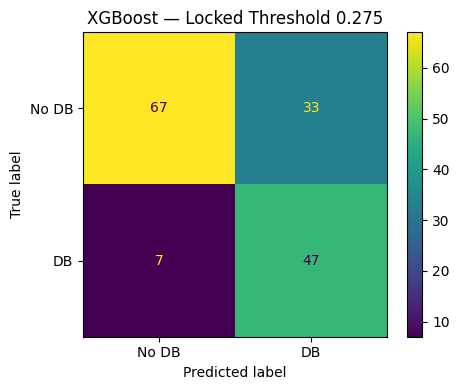

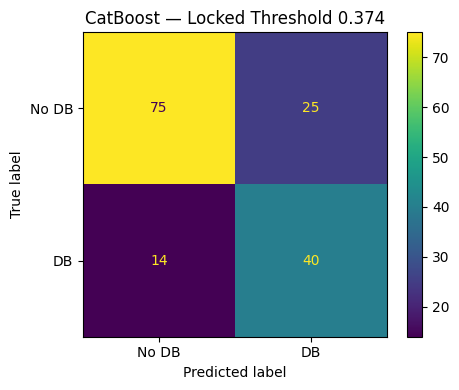

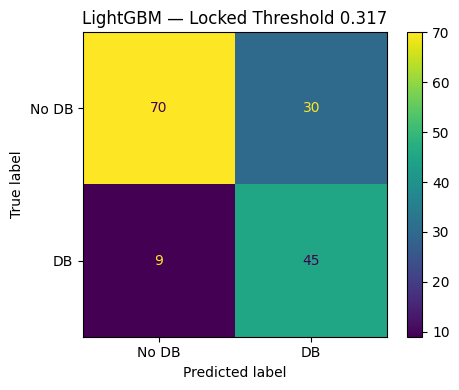

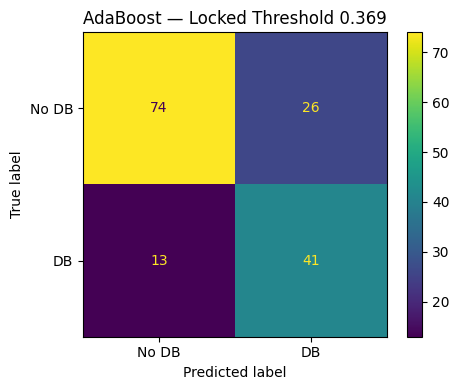

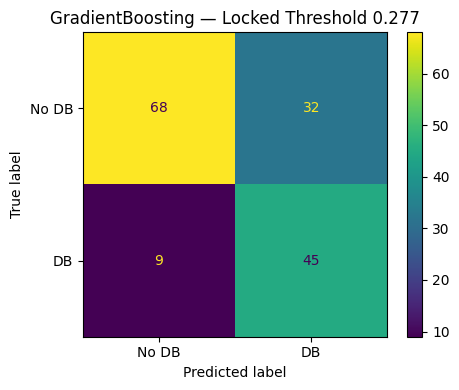

In [12]:
for name, stored in prediction_store.items():

    fig, ax = plt.subplots(figsize=(5,4))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        stored["pred_locked"],
        labels=[0,1],
        display_labels=[
            "No DB",
            "DB"
        ],
        values_format="d",
        ax=ax
    )

    ax.set_title(
        f"{name} — Locked Threshold "
        f"{locked_thresholds[name]:.3f}"
    )

    plt.tight_layout()

    plt.savefig(
        f"DB_V2_CM_{name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


## 12. ROC curves

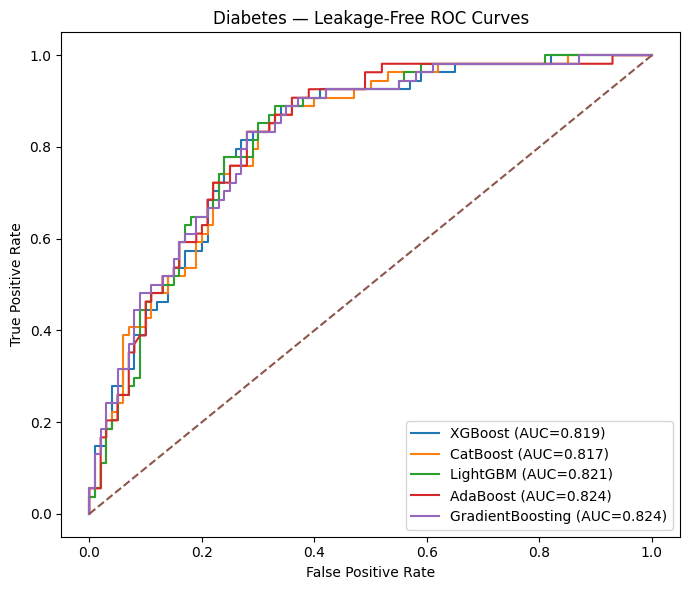

In [13]:
fig, ax = plt.subplots(figsize=(7,6))

for name, stored in prediction_store.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        stored["prob"]
    )

    auc_value = roc_auc_score(
        y_test,
        stored["prob"]
    )

    ax.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc_value:.3f})"
    )

ax.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(
    "Diabetes — Leakage-Free ROC Curves"
)
ax.legend()

plt.tight_layout()

plt.savefig(
    "DB_V2_ROC.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 13. Precision–Recall curves

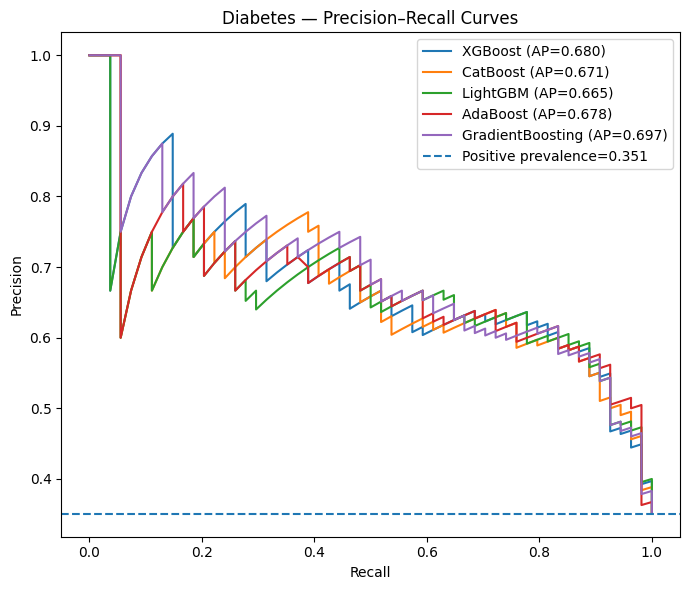

In [14]:
fig, ax = plt.subplots(figsize=(7,6))

for name, stored in prediction_store.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        stored["prob"]
    )

    ap = average_precision_score(
        y_test,
        stored["prob"]
    )

    ax.plot(
        recall,
        precision,
        label=f"{name} (AP={ap:.3f})"
    )

baseline = y_test.mean()

ax.axhline(
    baseline,
    linestyle="--",
    label=f"Positive prevalence={baseline:.3f}"
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(
    "Diabetes — Precision–Recall Curves"
)
ax.legend()

plt.tight_layout()

plt.savefig(
    "DB_V2_PR.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 14. Calibration curves and Brier scores

Calibration is evaluated in addition to discrimination because risk probabilities can be poorly calibrated even when ROC–AUC is acceptable.


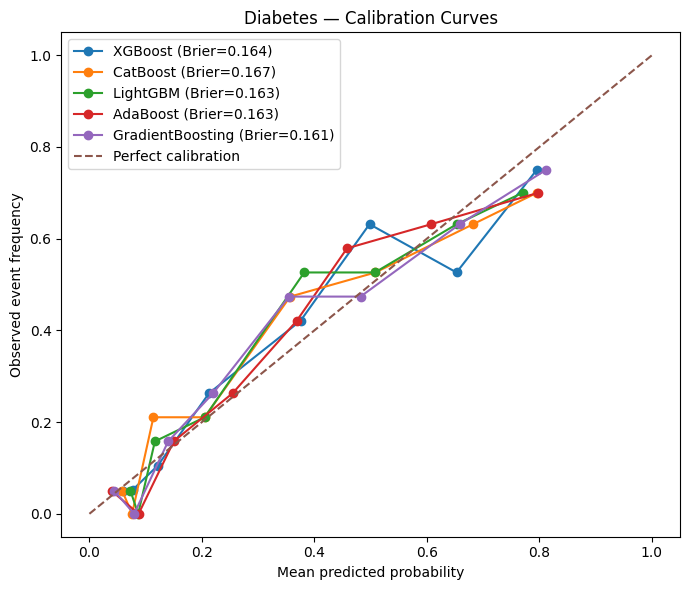

In [15]:
fig, ax = plt.subplots(figsize=(7,6))

for name, stored in prediction_store.items():

    frac_pos, mean_pred = calibration_curve(
        y_test,
        stored["prob"],
        n_bins=8,
        strategy="quantile"
    )

    brier = brier_score_loss(
        y_test,
        stored["prob"]
    )

    ax.plot(
        mean_pred,
        frac_pos,
        marker="o",
        label=f"{name} (Brier={brier:.3f})"
    )

ax.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Perfect calibration"
)

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed event frequency")
ax.set_title(
    "Diabetes — Calibration Curves"
)
ax.legend()

plt.tight_layout()

plt.savefig(
    "DB_V2_Calibration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 15. Repeated stratified cross-validation for statistical testing

The repeated observations are **matched validation splits**, not different evaluation metrics.

The same 5-fold × 5-repeat design is used for all five algorithms, yielding 25 matched observations per model.


In [16]:
outer_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

cv_rows = []

for name, estimator in best_estimators.items():

    print("Repeated CV:", name)

    scores = cross_validate(
        clone(estimator),
        X,
        y,
        cv=outer_cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    for split_id in range(
        len(scores["test_f1"])
    ):

        cv_rows.append({
            "Model": name,
            "Split": split_id + 1,
            "Accuracy":
                scores["test_accuracy"][split_id],
            "Balanced_Accuracy":
                scores["test_balanced_accuracy"][split_id],
            "Precision":
                scores["test_precision"][split_id],
            "Sensitivity":
                scores["test_recall"][split_id],
            "F1":
                scores["test_f1"][split_id],
            "ROC_AUC":
                scores["test_roc_auc"][split_id],
            "PR_AUC":
                scores["test_average_precision"][split_id]
        })

cv_df = pd.DataFrame(cv_rows)

cv_summary = cv_df.groupby("Model")[
    [
        "Accuracy",
        "Balanced_Accuracy",
        "Precision",
        "Sensitivity",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ]
].agg(["mean","std"])

display(cv_summary)

cv_df.to_csv(
    "DB_V2_repeated_CV_scores.csv",
    index=False
)

cv_summary.to_csv(
    "DB_V2_repeated_CV_summary.csv"
)


Repeated CV: XGBoost
Repeated CV: CatBoost
Repeated CV: LightGBM
Repeated CV: AdaBoost
Repeated CV: GradientBoosting


Accuracy           Balanced_Accuracy           Precision  \
                      mean       std              mean       std      mean   
Model                                                                        
AdaBoost          0.756226  0.031145          0.761135  0.028359  0.622439   
CatBoost          0.766120  0.036145          0.771736  0.031940  0.635203   
GradientBoosting  0.772608  0.034945          0.774608  0.031891  0.646862   
LightGBM          0.751797  0.031736          0.756066  0.028696  0.618004   
XGBoost           0.752824  0.035030          0.757322  0.032220  0.619103   

                           Sensitivity                  F1            \
                       std        mean       std      mean       std   
Model                                                                  
AdaBoost          0.043325    0.777470  0.036939  0.690511  0.033576   
CatBoost          0.050284    0.790273  0.038692  0.703065  0.036679   
GradientBoosting  0.052705    0.781216  0.043867  0.706333  0.038421   
LightGBM          0.042882    0.770133  0.041654  0.684556  0.032255   
XGBoost           0.048603    0.772243  0.041034  0.686191  0.037766   

                   ROC_AUC              PR_AUC            
                      mean       std      mean       std  
Model                                                     
AdaBoost          0.835375  0.028425  0.723838  0.052453  
CatBoost          0.842984  0.027677  0.726389  0.052356  
GradientBoosting  0.840095  0.028736  0.730301  0.047253  
LightGBM          0.832301  0.031559  0.714859  0.056260  
XGBoost           0.835606  0.030288  0.723269  0.056852

## 16. Select the XAI model using training-only evidence

The XAI model is selected using training-only OOF balanced accuracy, with OOF ROC–AUC as a tie-breaker.  
The held-out test performance is not used to choose which model receives the detailed XAI analysis.


In [17]:
xai_model_name = threshold_df.sort_values(
    [
        "OOF_Balanced_Accuracy",
        "OOF_ROC_AUC"
    ],
    ascending=False
).iloc[0]["Model"]

print(
    "XAI model selected from training-only evidence:",
    xai_model_name
)

xai_pipeline = clone(
    best_estimators[xai_model_name]
)

xai_pipeline.fit(
    X_train,
    y_train
)

zero_transformer = (
    xai_pipeline.named_steps[
        "zero_as_missing"
    ]
)

imputer = (
    xai_pipeline.named_steps[
        "imputer"
    ]
)

scaler = (
    xai_pipeline.named_steps[
        "scaler"
    ]
)

base_model = (
    xai_pipeline.named_steps[
        "model"
    ]
)

# Transform without oversampling for explanation.
X_train_zero = zero_transformer.transform(
    X_train
)
X_test_zero = zero_transformer.transform(
    X_test
)

X_train_imp = imputer.transform(
    X_train_zero
)
X_test_imp = imputer.transform(
    X_test_zero
)

X_train_trans = scaler.transform(
    X_train_imp
)
X_test_trans = scaler.transform(
    X_test_imp
)

feature_names = list(X.columns)

X_train_trans_df = pd.DataFrame(
    X_train_trans,
    columns=feature_names,
    index=X_train.index
)

X_test_trans_df = pd.DataFrame(
    X_test_trans,
    columns=feature_names,
    index=X_test.index
)

print(
    "Underlying XAI estimator:",
    type(base_model)
)


XAI model selected from training-only evidence: AdaBoost
Underlying XAI estimator: <class 'sklearn.ensemble._weight_boosting.AdaBoostClassifier'>


## 17. SHAP global explanation — model-aware implementation

`TreeExplainer` is used for directly supported tree estimators.  
For AdaBoost or another unsupported estimator, a model-agnostic permutation SHAP explainer is used.

The background/reference data are derived from the **training set only**.


Using model-agnostic SHAP permutation explainer


PermutationExplainer explainer: 155it [00:17,  5.87it/s]                         


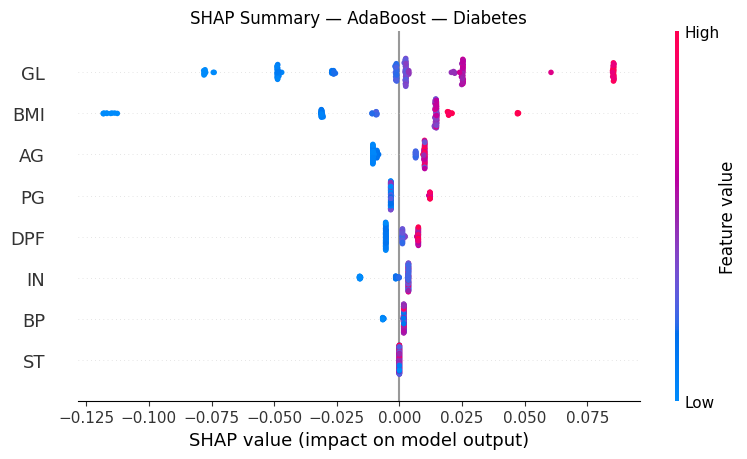

In [18]:
import shap

tree_supported = xai_model_name in [
    "XGBoost",
    "CatBoost",
    "LightGBM",
    "GradientBoosting"
]

if tree_supported:

    print("Using SHAP TreeExplainer")

    explainer = shap.TreeExplainer(
        base_model
    )

    shap_values = explainer.shap_values(
        X_test_trans_df
    )

    if isinstance(shap_values, list):
        shap_for_plot = shap_values[-1]
    else:
        shap_for_plot = shap_values

    shap_exp = None

else:

    print(
        "Using model-agnostic "
        "SHAP permutation explainer"
    )

    background = shap.sample(
        X_train_trans_df,
        min(
            100,
            len(X_train_trans_df)
        ),
        random_state=RANDOM_STATE
    )

    def predict_positive_probability(
        X_input
    ):
        arr = (
            X_input.values
            if isinstance(
                X_input,
                pd.DataFrame
            )
            else np.asarray(X_input)
        )

        return (
            base_model
            .predict_proba(arr)[:,1]
        )

    explainer = shap.Explainer(
        predict_positive_probability,
        background,
        algorithm="permutation"
    )

    shap_exp = explainer(
        X_test_trans_df,
        max_evals=
            2 * X_test_trans_df.shape[1] + 1
    )

    shap_for_plot = (
        shap_exp.values
    )

shap_array = np.asarray(
    shap_for_plot
)

if shap_array.ndim == 3:
    shap_array = shap_array[:, :, -1]

shap.summary_plot(
    shap_array,
    X_test_trans_df,
    feature_names=feature_names,
    show=False
)

plt.title(
    f"SHAP Summary — "
    f"{xai_model_name} — Diabetes"
)

plt.tight_layout()

plt.savefig(
    "DB_V2_SHAP_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 18. SHAP global mean absolute importance

,Feature,Mean_Absolute_SHAP
1,GL,0.031117
5,BMI,0.024648
7,AG,0.009544
0,PG,0.005585
6,DPF,0.005268
4,IN,0.004923
2,BP,0.002305
3,ST,0.000000


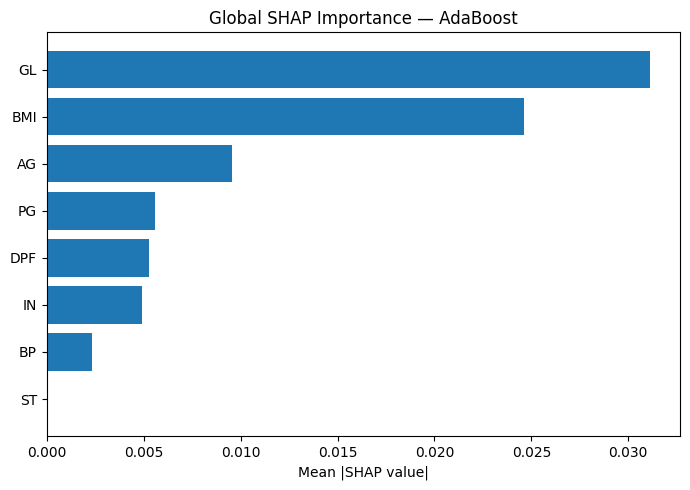

In [19]:
mean_abs_shap = np.abs(
    shap_array
).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP":
        mean_abs_shap
}).sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

display(
    shap_importance_df
)

shap_importance_df.to_csv(
    "DB_V2_SHAP_global_importance.csv",
    index=False
)

top = (
    shap_importance_df
    .head(8)
    .sort_values(
        "Mean_Absolute_SHAP"
    )
)

plt.figure(
    figsize=(7,5)
)

plt.barh(
    top["Feature"],
    top["Mean_Absolute_SHAP"]
)

plt.xlabel(
    "Mean |SHAP value|"
)

plt.title(
    f"Global SHAP Importance — "
    f"{xai_model_name}"
)

plt.tight_layout()

plt.savefig(
    "DB_V2_SHAP_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 19. Representative held-out test cases for local XAI

Representative diabetes and non-diabetes examples are chosen algorithmically rather than manually.  
Among correctly classified observations of each true class, the case whose calibrated probability is closest to the class-specific median is selected.

This avoids cherry-picking extreme 0.00/1.00 predictions.


In [20]:
selected_calibrated = (
    calibrated_models[
        xai_model_name
    ]
)

selected_prob = (
    selected_calibrated
    .predict_proba(X_test)[:,1]
)

selected_threshold = (
    locked_thresholds[
        xai_model_name
    ]
)

selected_pred = (
    selected_prob >= selected_threshold
).astype(int)

y_test_array = (
    y_test.to_numpy()
)

def representative_index(
    target_class
):

    candidates = np.where(
        (y_test_array == target_class)
        &
        (selected_pred == target_class)
    )[0]

    if len(candidates) == 0:
        candidates = np.where(
            y_test_array == target_class
        )[0]

    probs = selected_prob[
        candidates
    ]

    median_prob = np.median(
        probs
    )

    return int(
        candidates[
            np.argmin(
                np.abs(
                    probs - median_prob
                )
            )
        ]
    )

rep_neg = representative_index(0)
rep_pos = representative_index(1)

print(
    "Representative No-DB case:",
    rep_neg,
    "calibrated P(DB)=",
    round(
        selected_prob[rep_neg],
        4
    )
)

print(
    "Representative DB case:",
    rep_pos,
    "calibrated P(DB)=",
    round(
        selected_prob[rep_pos],
        4
    )
)


Representative No-DB case: 100 calibrated P(DB)= 0.1083
Representative DB case: 90 calibrated P(DB)= 0.596


## 20. Representative SHAP waterfall explanations

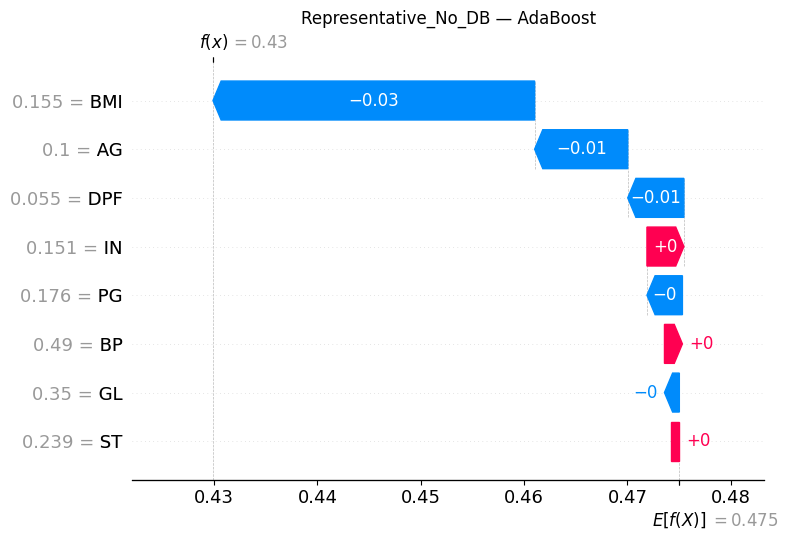

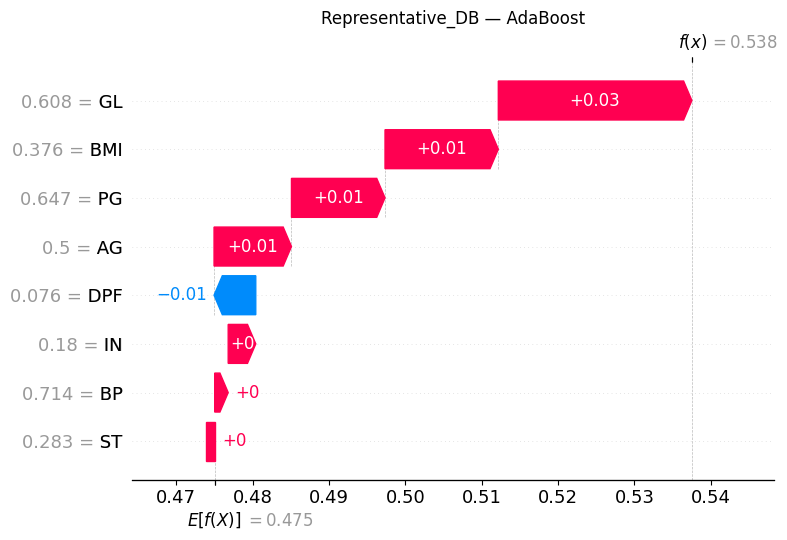

In [21]:
if tree_supported:

    expected = (
        explainer.expected_value
    )

    if isinstance(
        expected,
        (list, np.ndarray)
    ):
        expected_value = (
            np.asarray(
                expected
            ).ravel()[-1]
        )
    else:
        expected_value = expected

for label, pos in [
    ("Representative_No_DB", rep_neg),
    ("Representative_DB", rep_pos)
]:

    if not tree_supported:

        case_exp = shap_exp[pos]

    else:

        case_exp = shap.Explanation(
            values=shap_array[pos],
            base_values=expected_value,
            data=
                X_test_trans_df
                .iloc[pos]
                .values,
            feature_names=
                feature_names
        )

    shap.plots.waterfall(
        case_exp,
        max_display=8,
        show=False
    )

    plt.title(
        f"{label} — "
        f"{xai_model_name}"
    )

    plt.tight_layout()

    plt.savefig(
        f"DB_V2_SHAP_{label}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


## 21. LIME representative local explanations

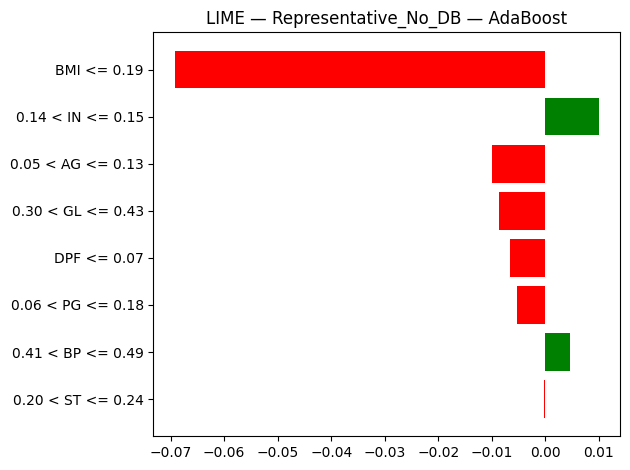

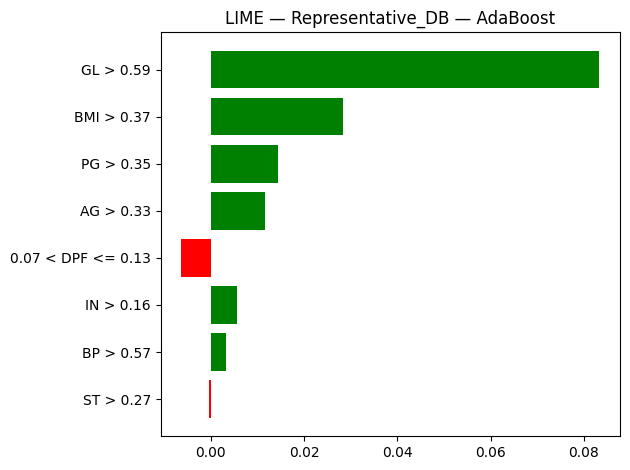

,Case,Rule,Weight
0,Representative_No_DB,BMI <= 0.19,-0.069252
1,Representative_No_DB,0.14 < IN <= 0.15,0.009964
2,Representative_No_DB,0.05 < AG <= 0.13,-0.009922
3,Representative_No_DB,0.30 < GL <= 0.43,-0.008611
4,Representative_No_DB,DPF <= 0.07,-0.006612
5,Representative_No_DB,0.06 < PG <= 0.18,-0.005368
6,Representative_No_DB,0.41 < BP <= 0.49,0.004493
7,Representative_No_DB,0.20 < ST <= 0.24,-0.000327
8,Representative_DB,GL > 0.59,0.083264
9,Representative_DB,BMI > 0.37,0.028297


In [22]:
from lime.lime_tabular import (
    LimeTabularExplainer
)

lime_explainer = (
    LimeTabularExplainer(
        training_data=
            X_train_trans_df.to_numpy(),
        feature_names=
            feature_names,
        class_names=[
            "No Diabetes",
            "Diabetes"
        ],
        mode="classification",
        discretize_continuous=True,
        random_state=RANDOM_STATE
    )
)

def lime_predict_fn(arr):
    return (
        base_model
        .predict_proba(arr)
    )

lime_rows = []

for label, pos in [
    ("Representative_No_DB", rep_neg),
    ("Representative_DB", rep_pos)
]:

    exp = (
        lime_explainer
        .explain_instance(
            X_test_trans_df
            .iloc[pos]
            .to_numpy(),
            lime_predict_fn,
            num_features=min(
                8,
                len(feature_names)
            )
        )
    )

    fig = exp.as_pyplot_figure()

    plt.title(
        f"LIME — "
        f"{label} — "
        f"{xai_model_name}"
    )

    plt.tight_layout()

    plt.savefig(
        f"DB_V2_LIME_{label}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    for rule, weight in exp.as_list():

        lime_rows.append({
            "Case": label,
            "Rule": rule,
            "Weight": weight
        })

lime_df = pd.DataFrame(
    lime_rows
)

display(
    lime_df
)

lime_df.to_csv(
    "DB_V2_LIME_representative_cases.csv",
    index=False
)


## 22. Manuscript-ready summary table

The primary revised interpretation should consider discrimination, sensitivity, specificity, F1-score, and calibration alongside raw accuracy.


In [23]:
manuscript_table = (
    test_results_df[
        test_results_df[
            "Threshold_Type"
        ] == "Training_Optimized"
    ][[
        "Model",
        "Threshold",
        "Accuracy",
        "Balanced_Accuracy",
        "Precision",
        "Sensitivity",
        "Specificity",
        "F1",
        "ROC_AUC",
        "PR_AUC",
        "Brier"
    ]]
    .copy()
)

percentage_columns = [
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Sensitivity",
    "Specificity",
    "F1",
    "ROC_AUC",
    "PR_AUC"
]

for col in percentage_columns:

    manuscript_table[col] = (
        100 * manuscript_table[col]
    ).round(2)

manuscript_table["Threshold"] = (
    manuscript_table[
        "Threshold"
    ].round(4)
)

manuscript_table["Brier"] = (
    manuscript_table[
        "Brier"
    ].round(4)
)

display(
    manuscript_table
)

manuscript_table.to_csv(
    "DB_V2_manuscript_summary_table.csv",
    index=False
)


,Model,Threshold,Accuracy,Balanced_Accuracy,Precision,Sensitivity,Specificity,F1,ROC_AUC,PR_AUC,Brier
1,XGBoost,0.2746,74.03,77.02,58.75,87.04,67.0,70.15,81.93,68.00,0.1645
3,CatBoost,0.3736,74.68,74.54,61.54,74.07,75.0,67.23,81.74,67.14,0.1670
5,LightGBM,0.3172,74.68,76.67,60.00,83.33,70.0,69.77,82.15,66.52,0.1634
7,AdaBoost,0.3690,74.68,74.96,61.19,75.93,74.0,67.77,82.38,67.75,0.1635
9,GradientBoosting,0.2772,73.38,75.67,58.44,83.33,68.0,68.70,82.43,69.70,0.1614


## 23. Revision outputs to retain

### Numerical outputs
- `DB_V2_hyperparameters.csv`
- `DB_V2_training_only_thresholds.csv`
- `DB_V2_test_results_default_and_optimized.csv`
- `DB_V2_results_with_95CI.csv`
- `DB_V2_repeated_CV_scores.csv`
- `DB_V2_repeated_CV_summary.csv`
- `DB_V2_manuscript_summary_table.csv`
- `DB_V2_SHAP_global_importance.csv`
- `DB_V2_LIME_representative_cases.csv`

### Figures
- model-specific confusion matrices
- `DB_V2_ROC.png`
- `DB_V2_PR.png`
- `DB_V2_Calibration.png`
- `DB_V2_SHAP_summary.png`
- `DB_V2_SHAP_importance.png`
- representative SHAP waterfall plots
- representative LIME plots

### Interpretation cautions
1. Do not claim that the corrected results reproduce the original 90.62% leakage-affected estimate.
2. Do not rank models using accuracy alone.
3. Treat the Pima dataset as a benchmark dataset rather than a representative contemporary clinical cohort.
4. SHAP/LIME identify variables influencing model predictions; they do not demonstrate causality.
5. Calibrated probabilities are model-estimated risks, not clinical certainty.
